In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
df=df[df['Volume']!=0]
df["Gmt time"]=df["Gmt time"].str.replace(".000","")
df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
df.reset_index(drop=True, inplace=True)

df=df[df.High!=df.Low]

df=df[0:1000]
pd.options.mode.copy_on_write = True

In [78]:
import pandas_ta as ta
from pandas_ta.volatility import kc 

# Bolinger Bands
df.ta.bbands(append=True, length=20, std=2)

# Initialize Keltner Channel Indictor
kc=kc(high=df['High'], low=df['Low'], close=df["Close"], window=20)

df['kc_upper'] = kc['KCUe_20_2']
df['kc_mid'] = kc['KCBe_20_2']
df['kc_lower']= kc['KCLe_20_2']

#Bolinger Band Upper - Keltner Channel Upper
bigSqueeze = df['BBU_20_2.0'] - kc['KCUe_20_2']

df['squeeze'] = bigSqueeze <=0
df

,Gmt time,Open,High,Low,Close,Volume,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,...,kc_upper,kc_mid,kc_lower,ema25,b3Bull,b3Bear,squeeze,isPivot,consolidation,pointpos
0,2022-09-01 13:30:00,259.337,259.547,257.896,257.927,2.0268,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,257.927000,False,False,False,0,False,NaN
1,2022-09-01 13:35:00,257.967,258.957,257.926,258.576,2.2260,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,257.976923,False,False,False,0,False,NaN
2,2022-09-01 13:40:00,258.547,259.377,258.396,258.737,2.2716,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,258.035391,False,False,False,0,False,NaN
3,2022-09-01 13:45:00,258.687,259.277,258.466,258.766,2.7444,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,258.091591,False,False,False,0,False,NaN
4,2022-09-01 13:50:00,258.726,259.147,258.496,259.087,2.4504,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,258.168161,False,False,False,0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2022-09-20 19:20:00,242.036,242.427,241.977,242.306,2.6076,239.505882,240.92015,242.334418,1.174055,...,242.358730,241.326548,240.294367,241.317277,False,False,True,0,False,NaN
996,2022-09-20 19:25:00,242.316,242.476,242.246,242.246,2.6916,239.519349,241.01660,242.513851,1.242446,...,242.391804,241.414115,240.436427,241.388717,False,False,False,0,False,NaN
997,2022-09-20 19:30:00,242.236,242.237,241.446,242.167,2.9532,239.612876,241.12210,242.631324,1.251834,...,242.522775,241.485819,240.448862,241.448585,True,False,False,0,False,NaN
998,2022-09-20 19:35:00,242.176,242.866,242.076,242.777,2.6904,239.714976,241.26865,242.822324,1.287920,...,242.697463,241.608788,240.520114,241.550771,True,False,False,0,False,NaN


In [102]:
def isPivot(candle, window):
    """
    function that detects if a candle is a pivot/fractal point
    args: candle index, window before and after candle to test if pivot
    returns: 1 if pivot high, 2 if pivot low, 3 if both and 0 default
    """
    window=11
    backcandles=60
    pivotHigh = 1
    pivotLow = 2
    
    if candle-window < 0 or candle+window >= len(df):
        return 0
        
    for i in range(candle-window, candle+window+1):
        
        if df.iloc[candle].Low > df.iloc[i].Low:
            pivotLow=0
        if df.iloc[candle].High < df.iloc[i].High:
            pivotHigh=0
            
    if (pivotHigh and pivotLow):
        return 3
    elif pivotHigh:
        return pivotHigh
    elif pivotLow:
        return pivotLow
    else:
        return 0
        
df['isPivot'] = df.apply(lambda x: isPivot(x.name,window), axis=1)

In [103]:
def detectStructure(candle, backcandles, window):
    """
    Attention! window should always be greater than the pivot window! to avoid look ahead bias
    """
    consolidation=False
    if (candle <= (backcandles+window)) or (candle+window+1 >= len(df)):
        return consolidation

    localdf = df.iloc[candle-backcandles-window:candle-window] #window must be greater than pivot window to avoid look ahead bias
    highs = localdf[localdf['isPivot'] == 1].High.tail(3).values
    lows = localdf[localdf['isPivot'] == 2].Low.tail(3).values
    
    if len(lows)==3:
        consolidation=True
    if len(highs)==3:
        consolidation=True
        
    return consolidation
    
df['consolidation'] = df.apply(lambda row: detectStructure(row.name, backcandles=backcandles, window=window), axis=1)
#df.to_csv('squezze.csv', index=False)

In [ ]:
def squezzeEntryArea(x):
    if (x['squeeze']==True) & (x['Close']>x['ema25']) & (x['consolidation']==True):
        return x['Low']-.50
    elif (x['squeeze']==True) & (x['Close']<x['ema25']) & (x['consolidation']==True):
        return x['High']+.50 
    else:
        return np.nan
        
df['pointpos'] = df.apply(lambda row: squezzeEntryArea(row), axis=1)

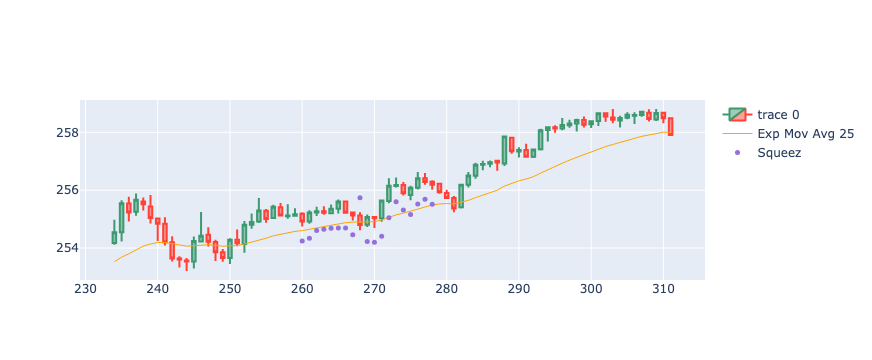

In [109]:
import plotly.io as pio
import plotly.graph_objects as go  
import numpy as np

'''
0:78
78:156
156:234 *
234:312 *
312:390
390:468
468:546
546:624
624:702
702:780
780:858
858:936
936:1014
1014:1092
1092:1170
1170:1248
1248:1326
1326:1404
1404:1482
1482:1560
1560:1638
1638:1716
1716:1794
1794:1872
1872:1950
1950:2028
2028:2106
'''
dfpl = df[234:312]

'''
fig = go.Figure(data=[
                    go.Candlestick(x=dfpl.index,
                                    open=dfpl['Open'],
                                    high=dfpl['High'],
                                    low=dfpl['Low'],
                                    close=dfpl['Close']),
                    go.Scatter(x=dfpl.index, y=dfpl['bb_upper'], line=dict(color='orange', width=1), name="BB Upper"),
                    go.Scatter(x=dfpl.index, y=dfpl['bb_mid'], line=dict(color='green', width=1), name="BB Mid"),
                    go.Scatter(x=dfpl.index, y=dfpl['bb_lower'], line=dict(color='orange', width=1), name="BB Lower"),
                    go.Scatter(x=dfpl.index, y=dfpl['kc_upper'], line=dict(color='purple', width=1), name="KC Upper"),
                    go.Scatter(x=dfpl.index, y=dfpl['kc_mid'], line=dict(color='yellow', width=1), name="KC Mid"),
                    go.Scatter(x=dfpl.index, y=dfpl['kc_lower'], line=dict(color='purple', width=1), name="KC Lower")
                ])
'''

fig = go.Figure(data=[
                    go.Candlestick(x=dfpl.index,
                                    open=dfpl['Open'],
                                    high=dfpl['High'],
                                    low=dfpl['Low'],
                                    close=dfpl['Close']),
                    go.Scatter(x=dfpl.index, y=dfpl['ema25'], line=dict(color='orange', width=1), name="Exp Mov Avg 25")
                ])

fig.add_scatter(x=dfpl.index, y=dfpl['pointpos'], mode="markers", marker=dict(size=5, color="MediumPurple"), name="Squeez")

#pointBreakIndex = dfpl[dfpl['consolidation'] != 0].index.tolist()
#pointBreakValues = list(filter((0.0).__ne__, dfpl['consolidation']))

#fig.add_scatter(x=pointBreakIndex, y=pointBreakValues, mode="markers", marker=dict(size=5, color="MediumseaGreen"), name="pivot")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()